<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/GBM_with_Interactive_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Quant Finance with Python

**Stochastic Model / Process**: Some type of model that involves some form of inherent randomness.

The specific model that will be modeled is **Geometric Brownian Motion**.

In [ ]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
def gbm(n_years=10, mu=0.07, sigma=0.15, steps_per_year=12):
  dt = 1/steps_per_year
  num_steps = int(n_years * steps_per_year)
  xi = np.random.normal(size=num_steps)
  rets = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
  return pd.DataFrame(rets)

<Axes: >

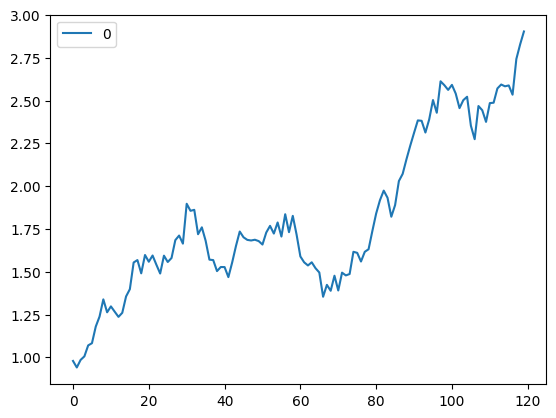

In [ ]:
rets = gbm()
wealth_index = (1+rets).cumprod()
wealth_index.plot()

In [ ]:
def gbm(n_years=10, n_scenarios=50, mu=0.07, sigma=0.15, steps_per_year=12):
  dt = 1/steps_per_year
  num_steps = int(n_years * steps_per_year)
  xi = np.random.normal(size=(num_steps, n_scenarios))
  rets = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
  return pd.DataFrame(rets)

<Axes: >

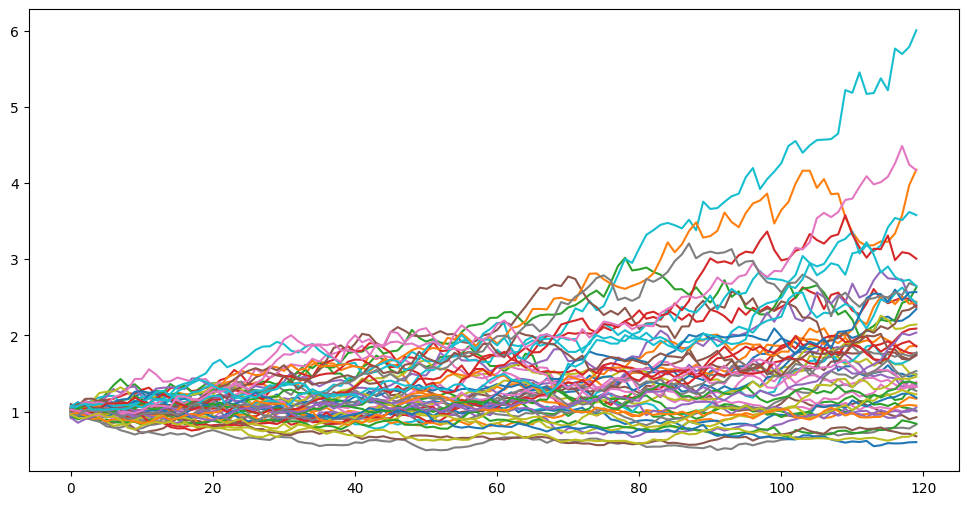

In [ ]:
rets = gbm()
wealth_index = (1+rets).cumprod()
wealth_index.plot(legend=False, figsize=(12, 6))

In [ ]:
def gbm(n_years=10, n_scenarios=50, mu=0.07, sigma=0.15, steps_per_year=12, s_0=100):
  dt = 1/steps_per_year
  num_steps = n_years * steps_per_year
  xi = np.random.normal(size=(num_steps, n_scenarios))
  rets = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
  rets = pd.DataFrame(rets)
  return s_0*(1+rets).cumprod()

<Axes: >

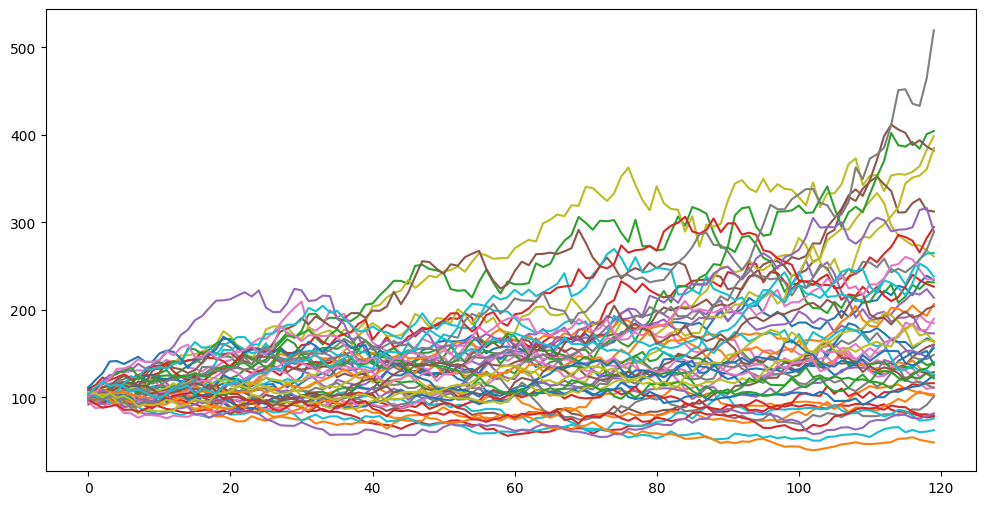

In [ ]:
gbm().plot(legend=False, figsize=(12, 6))

In [ ]:
def gbm(n_years=10, n_scenarios=100, mu=0.07, sigma=0.15, steps_per_year=12, s_0=100):
  dt = 1/steps_per_year
  num_steps = n_years * steps_per_year
  rets_p_1 = np.random.normal(loc=((1+mu)**dt), scale=sigma*np.sqrt(dt), size=(num_steps, n_scenarios))
  rets_p_1 = pd.concat([pd.DataFrame(np.ones((1, n_scenarios))), pd.DataFrame(rets_p_1)], ignore_index=True)
  return s_0*rets_p_1.cumprod()
  # More efficient for time effectiveness

<Axes: >

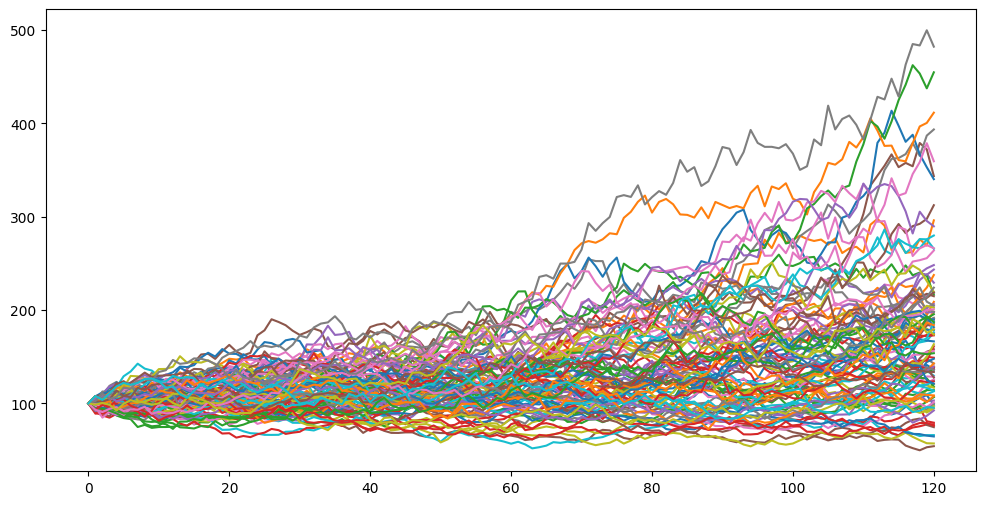

In [ ]:
gbm().plot(legend=False, figsize=(12, 6))

**Interactive Plotting**

In [ ]:
import ipywidgets as widgets

In [ ]:
def func(n):
  return n * 2

In [ ]:
widgets.interact(func, n=(0, 100, 2)) # Start, Stop, Step

interactive(children=(IntSlider(value=50, description='n', step=2), Output()), _dom_classes=('widget-interact'…

<function __main__.func(n)>

In [ ]:
def interactive_gbm(n_years=10, n_scenarios=100, mu=0.07, sigma=0.15, s_0=100):
  prices = gbm(n_years=n_years, n_scenarios=n_scenarios, mu=mu, sigma=sigma, s_0=s_0)
  terminal_wealth = prices.iloc[-1]

  fig, (wealth_axis, hist_axis) = plt.subplots(nrows=1, ncols=2, sharey=True, gridspec_kw={'width_ratios':[2, 1]}, figsize=(24, 10))
  plt.subplots_adjust(wspace=0)

  prices.plot(ax=wealth_axis, legend=False, color="skyblue", alpha=0.3)
  wealth_axis.axhline(y=s_0, ls="--", color="black")
  terminal_wealth.plot.hist(ax=hist_axis, bins=50, ec='white', color = 'skyblue', orientation = 'horizontal')

In [ ]:
widgets.interactive(interactive_gbm, n_years=(1, 30), n_scenarios=(1, 1000, 10), mu=(-0.1, 0.1, 0.01), sigma=(0, 0.3, 0.01), s_0=(100, 1000))

interactive(children=(IntSlider(value=10, description='n_years', max=30, min=1), IntSlider(value=100, descript…